# Fast Cross-Validation over the Number of States

The [Gaussian HMM notebook](gaussian_hmm.ipynb) chooses the number of discrete
states $K$ by leave-one-out cross-validation: fit one model per candidate $K$,
score each on held-out sequences, and keep the best. Written as a loop over
candidates, that approach has a hidden cost. JAX compiles a program that is
specialized to the *shapes* of its arrays, and every $K$ gives the parameters a
different shape (a $K \times K$ transition matrix, $K$ emission means, ...). So a
sweep over eight values of $K$ traces and compiles eight programs, and the eight
fits run one after another.

`dynamax.hidden_markov_model.cross_validate_num_states` removes both costs by
making every candidate model the *same shape*. This notebook shows how it is
used, how it works, and when it helps.

## Setup

In [1]:
%%capture
try:
    import dynamax
except ModuleNotFoundError:
    print('installing dynamax')
    %pip install -q dynamax[notebooks]
    import dynamax

In [2]:
from functools import partial

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from jax import jit, vmap

from dynamax.hidden_markov_model import GaussianHMM
from dynamax.hidden_markov_model import cross_validate_num_states

## Simulate data

We use the same synthetic data as the Gaussian HMM notebook: a 5-state HMM with
two-dimensional emissions, and three training sequences of 100 time steps.

In [3]:
num_train_batches = 3
num_timesteps = 100

# Make an HMM and sample data and true underlying states
true_num_states = 5
emission_dim = 2
hmm = GaussianHMM(true_num_states, emission_dim)

# Specify parameters of the HMM
initial_probs = jnp.ones(true_num_states) / true_num_states
transition_matrix = 0.80 * jnp.eye(true_num_states) \
    + 0.15 * jnp.roll(jnp.eye(true_num_states), 1, axis=1) \
    + 0.05 / true_num_states
emission_means = jnp.column_stack([
    jnp.cos(jnp.linspace(0, 2 * jnp.pi, true_num_states + 1))[:-1],
    jnp.sin(jnp.linspace(0, 2 * jnp.pi, true_num_states + 1))[:-1],
    jnp.zeros((true_num_states, emission_dim - 2)),
    ])
emission_covs = jnp.tile(0.1**2 * jnp.eye(emission_dim), (true_num_states, 1, 1))

true_params, _ = hmm.initialize(initial_probs=initial_probs,
                                transition_matrix=transition_matrix,
                                emission_means=emission_means,
                                emission_covariances=emission_covs)

# Sample training data
train_key, _, _ = jr.split(jr.PRNGKey(0), 3)
f = vmap(partial(hmm.sample, true_params, num_timesteps=num_timesteps))
train_true_states, train_emissions = f(jr.split(train_key, num_train_batches))

all_num_states = list(range(2, 10))

## One model per candidate

This is the cross-validation helper from the Gaussian HMM notebook, with the
initialization moved out so we can reuse the same starting parameters below. It
fits the three leave-one-out folds in parallel with `vmap` inside one
`jit`-compiled program, and returns the held-out log likelihood of each fold.
Calling it once per candidate $K$ compiles one program per candidate.

In [4]:
def cross_validate_model(model, params, props, num_iters=100):
    # Split the training data into folds.
    folds = jnp.stack([
        jnp.concatenate([train_emissions[:i], train_emissions[i+1:]])
        for i in range(num_train_batches)
    ])

    def _fit_fold(y_train, y_val):
        fit_params, train_lps = model.fit_em(params, props, y_train,
                                             num_iters=num_iters, verbose=False)
        return model.marginal_log_prob(fit_params, y_val)

    val_lls = jit(vmap(_fit_fold))(folds, train_emissions)
    return val_lls.mean(), val_lls

In [5]:
%%time
test_hmms = [GaussianHMM(num_states, emission_dim, transition_matrix_stickiness=10.)
             for num_states in all_num_states]

# Initialize each candidate with K-Means on the full training set (keep these to reuse below)
inits = [test_hmm.initialize(key=jr.PRNGKey(0), method="kmeans", emissions=train_emissions)
         for test_hmm in test_hmms]

results = [cross_validate_model(test_hmm, params, props)
           for test_hmm, (params, props) in zip(test_hmms, inits)]
avg_val_lls_per_model, all_val_lls_per_model = tuple(zip(*results))

CPU times: user 29 s, sys: 7.39 s, total: 36.4 s
Wall time: 11.2 s


## Compiling the whole sweep once

`cross_validate_num_states` fits all candidates and all folds in a **single**
compiled program. The idea is to *pad* every candidate to the largest number of
states, $K_\max$, and make the extra states inert:

* **Same shapes.** Every model gets $K_\max$ states, so their parameters stack
  into one batch and `vmap` can run all models (and all folds) at once.
* **Masking.** Padded states get zero initial probability, zero incoming
  transition probability, and $-\infty$ emission log-likelihood, so the forward-backward
  algorithm never assigns them posterior mass. After each M-step the initial
  distribution and transition matrix are re-masked, so the padded states stay
  inert throughout EM. The fit of the $k$ live states is the same as for an
  unpadded $k$-state model.
* **One random initialization.** A Dirichlet draw is a normalized vector of
  independent Gamma variables, so one padded Gamma sample provides the random
  initial distribution and transition matrix of every candidate.

None of this touches the models' own `e_step` or `m_step`; the masking wraps them.
The result is one trace, one compile, and one batched dispatch for the entire sweep.

In [6]:
%%time
avg_val_lls, all_val_lls = cross_validate_num_states(
    GaussianHMM, all_num_states, train_emissions, jr.PRNGKey(0),
    num_iters=100, init_method="kmeans",
    model_kwargs=dict(emission_dim=emission_dim, transition_matrix_stickiness=10.))

CPU times: user 8.2 s, sys: 7.17 s, total: 15.4 s
Wall time: 2.39 s


## Compare the two

The call above drew its own random initialization, so its curve need not match
the per-candidate loop exactly: below the true number of states the model is
misspecified and EM lands in different local optima from different starting
points. To compare like with like, pass the *same* initial parameters to both
methods with `initial_params`. The two then agree up to float32 rounding
(exactly in float64): the padding changes nothing about the fit of the live states.

max |difference| with the same initialization: 0.00020599365234375
best K, one model per K:           5
best K, cross_validate_num_states: 5


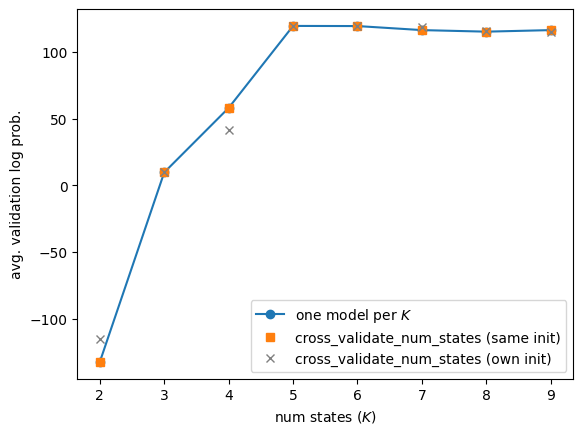

In [7]:
avg_val_lls_same_init, _ = cross_validate_num_states(
    GaussianHMM, all_num_states, train_emissions, jr.PRNGKey(0),
    num_iters=100, initial_params=inits,
    model_kwargs=dict(emission_dim=emission_dim, transition_matrix_stickiness=10.))

plt.plot(all_num_states, avg_val_lls_per_model, '-o', label='one model per $K$')
plt.plot(all_num_states, avg_val_lls_same_init, 's', label='cross_validate_num_states (same init)')
plt.plot(all_num_states, avg_val_lls, 'x', color='gray', label='cross_validate_num_states (own init)')
plt.xlabel("num states ($K$)")
plt.ylabel("avg. validation log prob.")
plt.legend()

print("max |difference| with the same initialization:",
      float(jnp.abs(jnp.stack(avg_val_lls_per_model) - avg_val_lls_same_init).max()))
print("best K, one model per K:          ", all_num_states[int(jnp.argmax(jnp.stack(avg_val_lls_per_model)))])
print("best K, cross_validate_num_states:", all_num_states[int(jnp.argmax(avg_val_lls))])

## When does this help?

The per-candidate loop pays one trace-and-compile per value of $K$; the padded
sweep pays one. That saving is a fixed cost, so its share of the total shrinks
as the data grows, but it does not go away: measured with 20x longer sequences
and 10x higher-dimensional emissions, the padded sweep was still faster overall.
The compile saving also grows with the number of candidates and with the size
of the model (bigger programs take longer to compile).

Execution time is a wash at these state counts. Every candidate does the work
of a $K_\max$-state model, but for small $K$ the forward-backward step is
dominated by fixed overhead rather than arithmetic, so the padded sweep runs
its 24 fits in about the same time as the eight sequential ones. For sweeps up
to very large $K$ the $O(K_\max^2)$ transition computations would add up, and
holding all models' posteriors at once takes more memory than one model at a
time.

A few practical notes:

* Emission parameters are still initialized per candidate on the host
  (`init_method="kmeans"` for the Gaussian HMMs, `"prior"` for the others).
* Models whose M-step depends explicitly on the number of states (currently
  `SharedCovarianceGaussianHMM`) are not exactly equivalent under padding.
* The general lesson applies beyond model selection: when JAX seems slow on
  many small problems, look for a way to give them one shape.